In [37]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

In [38]:
class PrunableLinear(nn.Module):
    def __init__(self, in_features, out_features):
        super(PrunableLinear, self).__init__()
        self.weight = nn.Parameter(torch.nn.init.kaiming_uniform_(
            torch.empty(out_features, in_features)))
        self.bias = nn.Parameter(torch.zeros(out_features))
        self.gate_scores = nn.Parameter(torch.ones(out_features, in_features) * 2.0)

    def forward(self, x):
        gates = torch.sigmoid(self.gate_scores)
        pruned_weights = self.weight * gates
        return nn.functional.linear(x, pruned_weights, self.bias)

    def get_gates(self):
        return torch.sigmoid(self.gate_scores)

In [39]:
class SelfPruningNet(nn.Module):
    def __init__(self):
        super(SelfPruningNet, self).__init__()
        self.flatten = nn.Flatten()
        self.fc1 = PrunableLinear(32 * 32 * 3, 512)
        self.fc2 = PrunableLinear(512, 256)
        self.fc3 = PrunableLinear(256, 10)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x

    def sparsity_loss(self):
        total = 0
        for module in self.modules():
            if isinstance(module, PrunableLinear):
                gates = module.get_gates()
                total += gates.sum()
        return total

In [40]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False, num_workers=2)

In [41]:
def train(model, optimizer, criterion, loader, lambda_sparse, device):
    model.train()
    total_loss = 0
    for inputs, labels in loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        cls_loss = criterion(outputs, labels)
        sp_loss = model.sparsity_loss()
        loss = cls_loss + lambda_sparse * sp_loss
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

In [42]:
def evaluate(model, loader, device):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)
    return 100 * correct / total

def sparsity_level(model, threshold=1e-2):
    total = 0
    pruned = 0
    for module in model.modules():
        if isinstance(module, PrunableLinear):
            gates = torch.sigmoid(module.gate_scores)
            total += gates.numel()
            pruned += (gates < threshold).sum().item()
    return 100 * pruned / total

In [43]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
criterion = nn.CrossEntropyLoss()
lambdas = [1e-5, 5e-5, 2e-4]
results = []

EPOCHS = 30
WARMUP = 8

for lam in lambdas:
    print(f"\nTraining with lambda = {lam}")
    model = SelfPruningNet().to(device)

    weight_params = [p for n, p in model.named_parameters() if 'gate' not in n]
    gate_params   = [p for n, p in model.named_parameters() if 'gate' in n]

    optimizer = optim.Adam([
        {'params': weight_params, 'lr': 1e-3},
        {'params': gate_params,   'lr': 5e-3}
    ])
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

    for epoch in range(EPOCHS):
        model.train()
        total_loss = 0
        effective_lam = 0.0 if epoch < WARMUP else lam

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            cls_loss = criterion(outputs, labels)
            sp_loss  = model.sparsity_loss()
            loss = cls_loss + effective_lam * sp_loss
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        scheduler.step()
        if (epoch + 1) % 5 == 0:
            eff = f"{effective_lam:.0e}" if effective_lam > 0 else "warmup"
            print(f"  Epoch {epoch+1}/{EPOCHS} | Loss: {total_loss/len(train_loader):.4f} | λ={eff}")

    acc      = evaluate(model, test_loader, device)
    sparsity = sparsity_level(model)
    print(f"  Test Accuracy: {acc:.2f}% | Sparsity: {sparsity:.2f}%")
    results.append({"lambda": lam, "accuracy": acc, "sparsity": sparsity, "model": model})


Training with lambda = 1e-05
  Epoch 5/30 | Loss: 1.1130 | λ=warmup
  Epoch 10/30 | Loss: 9.4317 | λ=1e-05
  Epoch 15/30 | Loss: 4.1814 | λ=1e-05
  Epoch 20/30 | Loss: 3.0639 | λ=1e-05
  Epoch 25/30 | Loss: 2.6710 | λ=1e-05
  Epoch 30/30 | Loss: 2.5814 | λ=1e-05
  Test Accuracy: 55.46% | Sparsity: 34.43%

Training with lambda = 5e-05
  Epoch 5/30 | Loss: 1.1114 | λ=warmup
  Epoch 10/30 | Loss: 15.6787 | λ=5e-05
  Epoch 15/30 | Loss: 4.4968 | λ=5e-05
  Epoch 20/30 | Loss: 3.1671 | λ=5e-05
  Epoch 25/30 | Loss: 2.7744 | λ=5e-05
  Epoch 30/30 | Loss: 2.6927 | λ=5e-05
  Test Accuracy: 57.73% | Sparsity: 76.44%

Training with lambda = 0.0002
  Epoch 5/30 | Loss: 1.1136 | λ=warmup
  Epoch 10/30 | Loss: 28.4669 | λ=2e-04
  Epoch 15/30 | Loss: 5.3698 | λ=2e-04
  Epoch 20/30 | Loss: 3.2675 | λ=2e-04
  Epoch 25/30 | Loss: 2.6789 | λ=2e-04
  Epoch 30/30 | Loss: 2.5492 | λ=2e-04
  Test Accuracy: 53.04% | Sparsity: 97.07%


In [44]:
print(f"\n{'Lambda':<12} {'Test Accuracy (%)':<22} {'Sparsity Level (%)'}")
print("-" * 55)
for r in results:
    print(f"{r['lambda']:<12} {r['accuracy']:<22.2f} {r['sparsity']:.2f}")


Lambda       Test Accuracy (%)      Sparsity Level (%)
-------------------------------------------------------
1e-05        55.46                  34.43
5e-05        57.73                  76.44
0.0002       53.04                  97.07


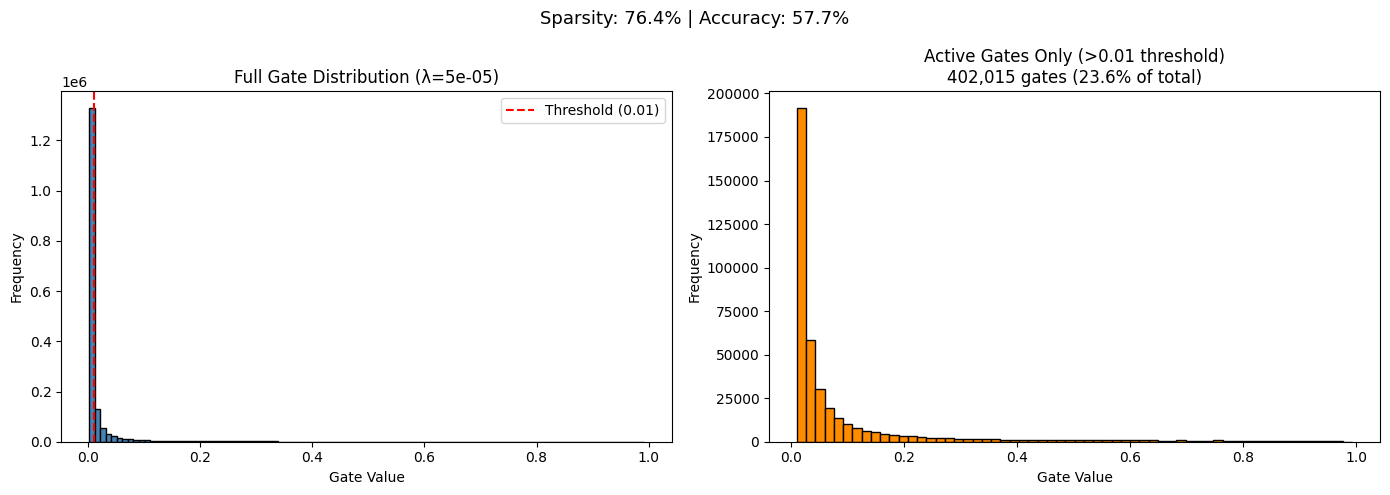


Gate Statistics:
  Total gates:    1,706,496
  Pruned (<0.01): 1,304,481 (76.4%)
  Active (>=0.01): 402,015 (23.6%)
  Mean gate value: 0.0243
  Max gate value:  0.9927


In [46]:
best = max(results, key=lambda r: r['accuracy'])
best_model = best['model']

all_gates = []
for module in best_model.modules():
    if isinstance(module, PrunableLinear):
        gates = module.get_gates().detach().cpu().numpy().flatten()
        all_gates.extend(gates)

all_gates = np.array(all_gates)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(all_gates, bins=100, color='steelblue', edgecolor='black')
axes[0].axvline(x=0.01, color='red', linestyle='--', label='Threshold (0.01)')
axes[0].set_xlabel("Gate Value")
axes[0].set_ylabel("Frequency")
axes[0].set_title(f"Full Gate Distribution (λ={best['lambda']})")
axes[0].legend()

active_gates = all_gates[all_gates >= 0.01]
axes[1].hist(active_gates, bins=60, color='darkorange', edgecolor='black')
axes[1].set_xlabel("Gate Value")
axes[1].set_ylabel("Frequency")
axes[1].set_title(f"Active Gates Only (>{0.01} threshold)\n{len(active_gates):,} gates ({100*len(active_gates)/len(all_gates):.1f}% of total)")

plt.suptitle(f"Sparsity: {best['sparsity']:.1f}% | Accuracy: {best['accuracy']:.1f}%", fontsize=13)
plt.tight_layout()
plt.savefig("gate_distribution.png", dpi=150)
plt.show()

print(f"\nGate Statistics:")
print(f"  Total gates:    {len(all_gates):,}")
print(f"  Pruned (<0.01): {(all_gates < 0.01).sum():,} ({100*(all_gates<0.01).mean():.1f}%)")
print(f"  Active (>=0.01): {(all_gates >= 0.01).sum():,} ({100*(all_gates>=0.01).mean():.1f}%)")
print(f"  Mean gate value: {all_gates.mean():.4f}")
print(f"  Max gate value:  {all_gates.max():.4f}")